# Single-Cell RNA-seq Analysis with MANTRA

This tutorial demonstrates a full MANTRA workflow on real single-cell RNA-seq
data from ALL (acute lymphoblastic leukemia) patients and healthy donors.
The dataset contains 36,313 cells across 18 samples and 15 cell types.

We will:

1. Load and explore the scRNA-seq data
2. Select highly variable genes
3. Aggregate to pseudo-bulk (samples x cell types x genes)
4. Normalize and fit MANTRA
5. Interpret factors: sample scores, cell type loadings, gene loadings
6. Run pathway enrichment (GSEA) on gene loadings
7. Run downstream analysis: UMAP, clustering, metadata associations
8. Visualize results

## 1. Load and Explore the Data

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantra

sc.settings.verbosity = 1

/Users/Buettner/projects/MANTRA/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = sc.read_h5ad("RNA.h5ad")
print(adata)
print(f"\nSamples: {adata.obs['sample'].nunique()}")
print(f"Cell types: {adata.obs['Ctype'].nunique()}")

AnnData object with n_obs × n_vars = 36313 × 20235
    obs: 'sample', 'Ctype', 'perc.mito', 'nCount_RNA', 'nFeature_RNA'
    layers: 'counts'

Samples: 18
Cell types: 15


In [3]:
# Cross-tabulate samples x cell types
ct = adata.obs.groupby(["sample", "Ctype"]).size().unstack(fill_value=0)
print(f"Samples x Cell types matrix: {ct.shape}")
ct

Samples x Cell types matrix: (18, 15)


Ctype,CD4_Early_Activation,CD4_Naive,CD8_Cytotoxic,CD8_EffectorMemory,CD8_Naive,CD14_Monocyte,CD16_Monocyte,CD16_NK,CD56_NK,Exhausted_T,Mature_B,NKT,Unknown,cDC,pDC
sample,,,,,,,,,,,,,,,
1154,16,60,12,89,104,15,29,31,325,9,244,79,10,8,1
PAYKGI,27,638,2,33,27,63,61,2,18,58,322,19,13,3,0
PAYLNH,9,437,1,26,115,149,19,1,5,2,78,8,3,111,5
PAYSBA,36,407,6,132,124,193,139,11,44,2,85,96,4,3,66
PAYUZJ,43,221,12,153,152,139,68,10,107,32,134,43,8,1,4
PAYUZM,51,522,6,71,149,82,109,20,99,17,489,281,19,0,0
PAYWJZ,28,667,0,2,285,1,0,3,5,0,10,0,0,0,1
PAYWKL,23,68,27,14,27,13,0,40,43,15,107,57,12,12,1
PAYYBG,9,165,5,193,213,1295,166,18,11,2,140,32,1,455,0


## 2. Feature Selection

With 20,000+ genes, we first select the most informative ones. Highly variable
gene (HVG) selection keeps features with the most biological signal while
reducing computational cost.

In [4]:
# Work on a copy to keep the original intact
adata_hvg = adata.copy()

# HVG selection requires normalized counts
sc.pp.normalize_total(adata_hvg, target_sum=1e4)
sc.pp.log1p(adata_hvg)

hvg_mask = mantra.pp.highly_variable_features(adata_hvg, n_top=2000)
print(f"Selected {hvg_mask.sum()} highly variable genes")

# Apply the mask to the original (unnormalized) data
adata_sub = adata[:, hvg_mask].copy()
print(f"Subsetted AnnData: {adata_sub.shape}")

Selected 2000 highly variable genes
Subsetted AnnData: (36313, 2000)


## 3. Pseudo-bulk Aggregation

MANTRA operates on 3rd-order tensors. We aggregate single-cell data into a
pseudo-bulk tensor of shape (samples x cell_types x genes) by averaging
gene expression per sample-cell type group.

Groups with fewer than `min_cells` cells are set to NaN (handled automatically
by MANTRA's missing value masking).

In [5]:
tensor, metadata = mantra.pp.pseudobulk(
    adata_sub,
    sample_key="sample",
    slice_key="Ctype",
    agg_func="mean",
    min_cells=5,
)

print(f"Tensor shape: {tensor.shape}  (samples x cell_types x genes)")
print(f"Samples: {metadata['sample_names'][:5]}...")
print(f"Cell types: {metadata['slice_names']}")

# Check missingness
import torch

n_missing = torch.isnan(tensor[:, :, 0]).sum().item()
n_total = tensor.shape[0] * tensor.shape[1]
print(f"\nMissing groups: {n_missing}/{n_total} ({100*n_missing/n_total:.1f}%)")

Tensor shape: torch.Size([18, 15, 2000])  (samples x cell_types x genes)
Samples: ['1154', 'PAYKGI', 'PAYLNH', 'PAYSBA', 'PAYUZJ']...
Cell types: ['CD14_Monocyte', 'CD16_Monocyte', 'CD16_NK', 'CD4_Early_Activation', 'CD4_Naive', 'CD56_NK', 'CD8_Cytotoxic', 'CD8_EffectorMemory', 'CD8_Naive', 'Exhausted_T', 'Mature_B', 'NKT', 'Unknown', 'cDC', 'pDC']

Missing groups: 76/270 (28.1%)


## 4. Normalize

Center and scale features across samples and cell types.

In [6]:
tensor_norm = mantra.pp.normalize(tensor, center=True, scale=True)
print(f"Normalized tensor shape: {tensor_norm.shape}")

Normalized tensor shape: torch.Size([18, 15, 2000])


## 5. Fit MANTRA

We fit a MANTRA model with 10 factors. The Horseshoe prior with ARD
(automatic relevance determination) will automatically shrink unused factors
towards zero.

In [7]:
model = mantra.MANTRA(
    observations=tensor_norm,
    R=10,
    use_gpu=False,
)

# Assign meaningful names from metadata
model.sample_names = metadata["sample_names"]
model.slice_names = metadata["slice_names"]
model.feature_names = [metadata["feature_names"]]

print(model)

MANTRA Model
  n_views:    1
  n_samples:  100
  n_factors:  10
  n_features: view_0: 2000
  trained:    False
  device:     cpu


In [8]:
from mantra.inference.callbacks import EarlyStoppingCallback

history, stopped_early = model.fit(
    n_epochs=3000,
    learning_rate=0.005,
    seed=42,
    callbacks=[EarlyStoppingCallback(patience=100)],
)
print(f"\nFinal ELBO: {history[-1]:.2f}")
print(f"Epochs run: {len(history)}")
print(f"Early stopped: {stopped_early}")

Training:   0%|          | 0/3000 [00:00<?, ?it/s]

Training:   0%|          | 0/3000 [00:01<?, ?it/s, ELBO=720556.25]

Training:   0%|          | 1/3000 [00:01<1:36:45,  1.94s/it, ELBO=720556.25]

Training:   0%|          | 1/3000 [00:02<1:36:45,  1.94s/it, ELBO=718037.23]

Training:   0%|          | 9/3000 [00:02<08:21,  5.96it/s, ELBO=718037.23]  

...

Training: 100%|█████████▉| 2988/3000 [00:35<00:00, 85.33it/s, ELBO=98098.72]

Training: 100%|█████████▉| 2998/3000 [00:35<00:00, 87.07it/s, ELBO=98098.72]

Training: 100%|█████████▉| 2998/3000 [00:35<00:00, 87.07it/s, ELBO=98259.93]

Training: 100%|██████████| 3000/3000 [00:35<00:00, 83.83it/s, ELBO=98259.93]


Final ELBO: 98259.93
Epochs run: 3000
Early stopped: False


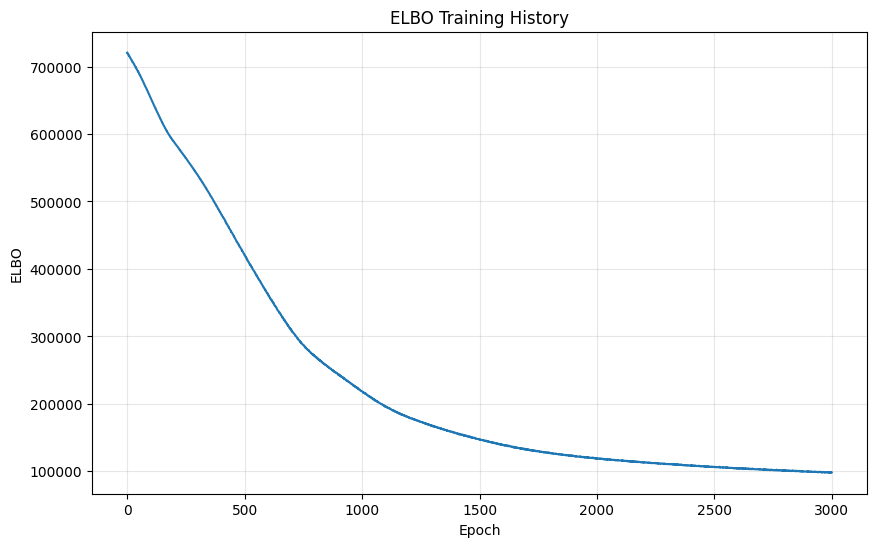

In [9]:
f = mantra.pl.plot_elbo(history)

## 6. Variance Explained

Identify which factors capture the most variance and select the most
informative ones.

In [10]:
r2 = mantra.tl.variance_explained(model)
print(f"Total R-squared: {r2['total']:.4f}")
print(f"\nPer-factor R-squared (sorted):")
print(r2["per_factor"])

Total R-squared: 0.9168

Per-factor R-squared (sorted):
                r2
Factor_9  0.275680
Factor_5  0.200488
Factor_0  0.196600
Factor_3  0.170890
Factor_4  0.167806
Factor_7  0.158183
Factor_1  0.147746
Factor_8  0.129835
Factor_6  0.128735
Factor_2  0.125952


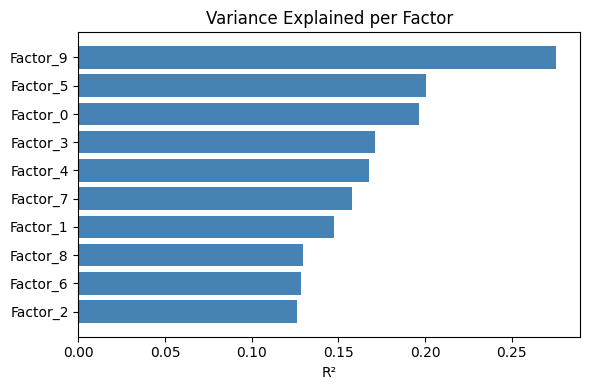

In [11]:
fig = mantra.pl.variance_explained(model)
plt.show()

In [12]:
# Filter to factors capturing 95% of explained variance
top_factors = mantra.tl.filter_factors(model, r2_thresh=0.95)
print(f"Top factors (95% cumulative R-squared): {top_factors}")

Top factors (95% cumulative R-squared): ['Factor_9', 'Factor_5', 'Factor_0', 'Factor_3', 'Factor_4']


## 7. Interpret Factor Structure

### 7a. Sample Embeddings (A1)

Sample embeddings show how each patient/donor scores on each factor.

In [13]:
A1 = model.get_sample_embeddings(as_df=True)
A1.head(10)

,Factor_0,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9
1154,3.197297,-2.330559,-1.145429,2.366200,2.714173,-1.617027,1.923287,-1.713951,2.791277,1.649662
PAYKGI,-0.173352,-0.774725,-1.893662,2.031486,-0.507458,-2.148079,-2.478256,-1.553593,0.443439,-0.375997
PAYLNH,0.159497,-1.442658,-1.055585,0.335236,-0.867965,-2.164509,-0.682117,-0.329396,0.091729,-0.332102
PAYSBA,1.345544,0.555471,-1.334274,1.390113,-1.035364,-1.740688,-1.380152,-0.370418,-1.255424,-0.375134
PAYUZJ,1.533046,0.333507,-1.790743,1.883084,-1.248295,-2.673909,-1.546553,-1.609273,-1.971972,-1.149230
PAYUZM,0.458259,-1.504088,-0.838120,-0.241125,0.338939,-1.714835,-0.551905,-0.328370,-0.376562,-0.855738
PAYWJZ,2.156671,-1.227412,-2.112627,-0.540295,-0.246635,-1.787191,-3.039367,0.347825,0.668326,-1.650200
PAYWKL,0.173817,-1.900355,-1.555552,1.089973,0.946926,-1.627575,-1.907799,-4.252339,-1.239174,1.346466
PAYYBG,2.069280,0.882139,-1.371028,1.926590,-0.875613,-2.730631,-1.792085,-1.003941,-2.251698,-0.932183
PAYYNY,3.231732,0.281418,-2.064535,1.455174,-2.286229,-1.443483,-1.010047,-1.513269,1.202232,2.051854


### 7b. Cell Type Loadings (A2)

Slice embeddings show how each cell type contributes to each factor.

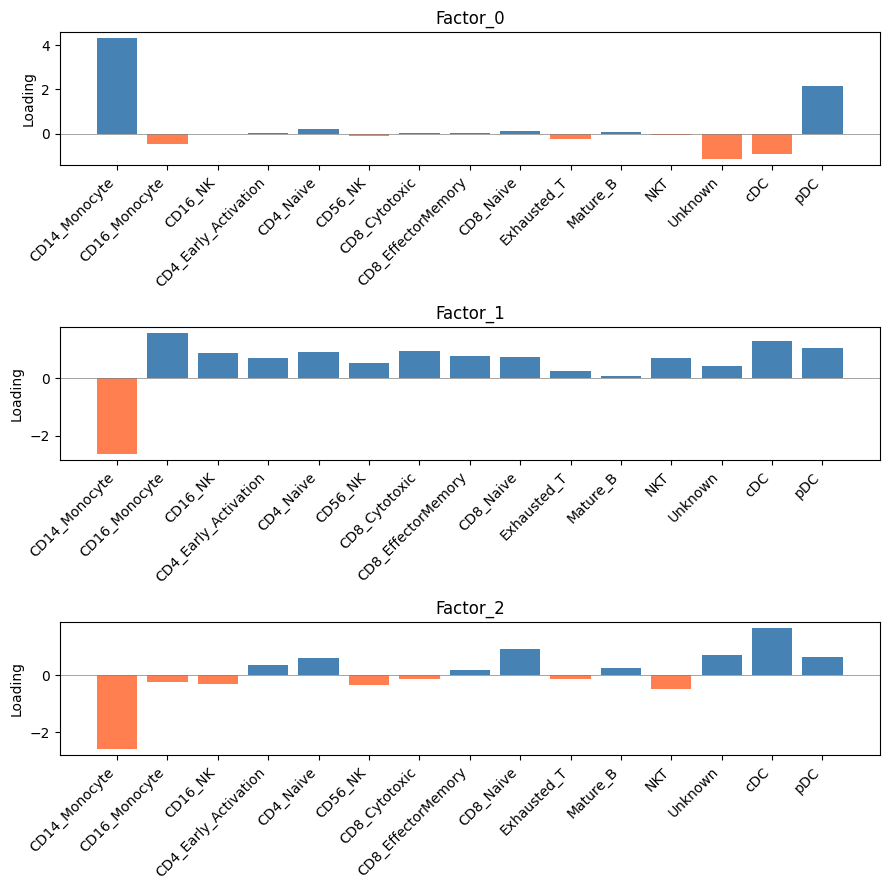

In [14]:
fig = mantra.pl.slice_weights(model, factor_idx=[0, 1, 2])
plt.show()

### 7c. Gene Loadings (A3)

Factor weights show the outer product of cell type x gene loadings per factor,
revealing which genes drive each factor in which cell types.

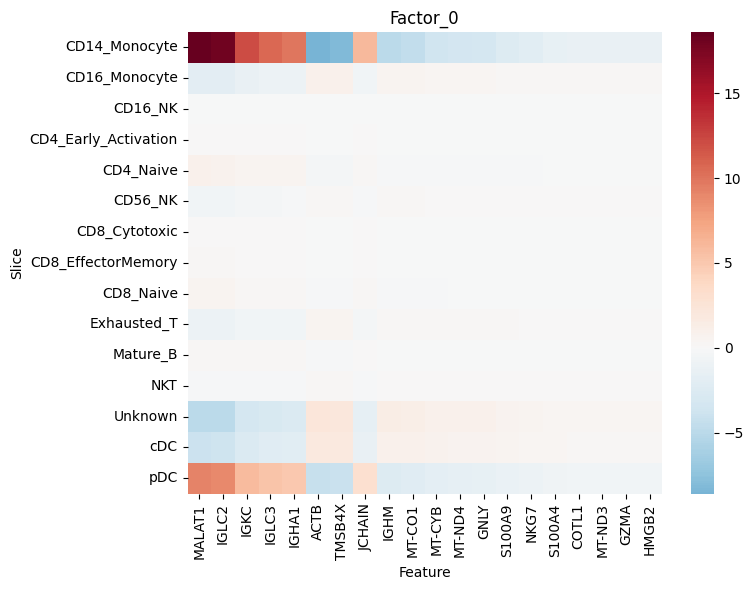

In [15]:
fig = mantra.pl.factor_weights(model, factor_idx=0, top=20)
plt.show()

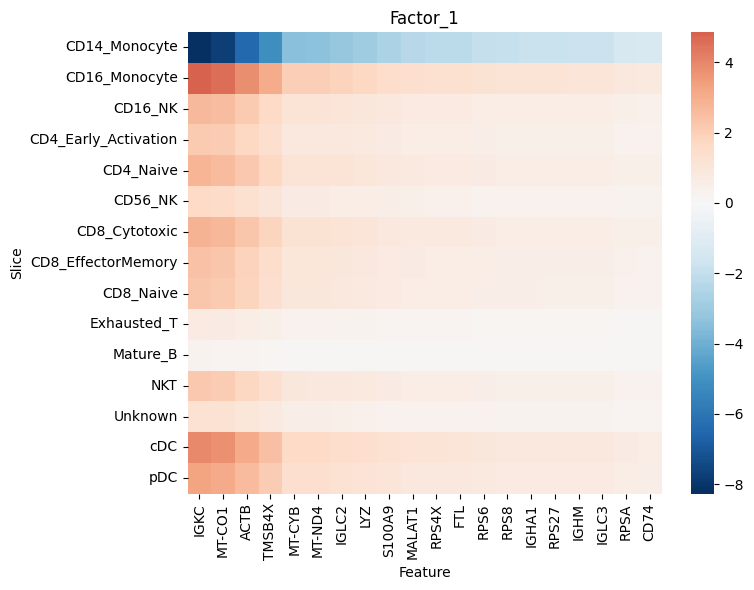

In [16]:
fig = mantra.pl.factor_weights(model, factor_idx=1, top=20)
plt.show()

## 8. Pathway Enrichment (GSEA)

MANTRA's feature embeddings (A3) capture which genes drive each factor.
We can run Gene Set Enrichment Analysis (GSEA) on these loadings to identify
enriched biological pathways per factor.

`mantra.tl.enrichment()` ranks genes by their loading magnitude per factor,
then runs GSEA prerank via gseapy against standard gene set databases.

In [17]:
# Run GSEA on the top factors using KEGG pathways
gsea_results = mantra.tl.enrichment(
    model,
    gene_sets="KEGG_2021_Human",
    method="gsea",
)

print(f"Enrichment results for {len(gsea_results)} factors")
for factor_name, df in gsea_results.items():
    n_sig = (df["FDR q-val"].astype(float) < 0.05).sum() if len(df) > 0 else 0
    print(f"  {factor_name}: {len(df)} terms tested, {n_sig} significant (FDR < 0.05)")

Enrichment results for 10 factors
  Factor_0: 92 terms tested, 0 significant (FDR < 0.05)
  Factor_1: 92 terms tested, 0 significant (FDR < 0.05)
  Factor_2: 92 terms tested, 0 significant (FDR < 0.05)
  Factor_3: 92 terms tested, 0 significant (FDR < 0.05)
  Factor_4: 92 terms tested, 0 significant (FDR < 0.05)
  Factor_5: 92 terms tested, 0 significant (FDR < 0.05)
  Factor_6: 92 terms tested, 0 significant (FDR < 0.05)
  Factor_7: 92 terms tested, 0 significant (FDR < 0.05)
  Factor_8: 92 terms tested, 0 significant (FDR < 0.05)
  Factor_9: 92 terms tested, 0 significant (FDR < 0.05)


In [18]:
# Show top enriched pathways for the first factor
first_factor = list(gsea_results.keys())[0]
res_df = gsea_results[first_factor].copy()

if len(res_df) > 0:
    res_df["FDR q-val"] = res_df["FDR q-val"].astype(float)
    top_terms = res_df.nsmallest(10, "FDR q-val")[["Term", "NES", "FDR q-val"]]
    print(f"\nTop 10 enriched KEGG pathways for {first_factor}:")
    print(top_terms.to_string(index=False))
else:
    print(f"No enrichment results for {first_factor}")


Top 10 enriched KEGG pathways for Factor_0:
                                   Term       NES  FDR q-val
       Regulation of actin cytoskeleton -1.613637   0.139821
                      Viral myocarditis -1.572761   0.209772
                Proteoglycans in cancer -1.567011   0.215341
          Amyotrophic lateral sclerosis -1.616432   0.237063
                         Focal adhesion -1.585689   0.237350
                 Rap1 signaling pathway -1.573509   0.238597
                Hippo signaling pathway -1.574343   0.279642
               Hepatocellular carcinoma -1.586589   0.304576
Neutrophil extracellular trap formation -1.534712   0.340979
                            Shigellosis -1.540274   0.342552


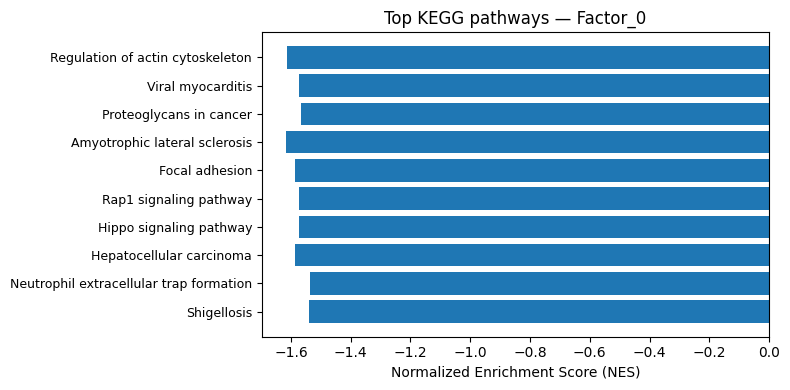

In [19]:
# Visualize top enriched pathways as a bar chart
def plot_enrichment(result_df, factor_name, top_n=10):
    """Plot top enriched pathways for a factor."""
    df = result_df.copy()
    if len(df) == 0:
        print(f"No results for {factor_name}")
        return
    df["FDR q-val"] = df["FDR q-val"].astype(float)
    df["NES"] = df["NES"].astype(float)
    top = df.nsmallest(top_n, "FDR q-val")
    if len(top) == 0:
        return

    fig, ax = plt.subplots(figsize=(8, max(3, len(top) * 0.4)))
    colors = ["#d62728" if nes > 0 else "#1f77b4" for nes in top["NES"]]
    ax.barh(range(len(top)), top["NES"].values, color=colors)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top["Term"].values, fontsize=9)
    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_title(f"Top KEGG pathways — {factor_name}")
    ax.invert_yaxis()
    plt.tight_layout()
    return fig

fig = plot_enrichment(gsea_results[first_factor], first_factor)
plt.show()

In [20]:
# You can also run enrichment with GO Biological Process or other gene set libraries
# Example (uncomment to run):
# go_results = mantra.tl.enrichment(model, gene_sets="GO_Biological_Process_2021", method="gsea")
#
# For ORA (overrepresentation analysis) instead of GSEA:
# ora_results = mantra.tl.enrichment(model, gene_sets="KEGG_2021_Human", method="ora", top_n=100)

## 9. Downstream Analysis

### 9a. Metadata and Cache Setup

MANTRA bridges to scanpy's ecosystem by caching sample embeddings as an
AnnData object. We can attach metadata for coloring plots.

In [21]:
# Create a simple patient/donor label
sample_labels = ["patient" if s != "1154" else "healthy" for s in metadata["sample_names"]]
mantra.tl.add_metadata(model, "condition", sample_labels)

### 9b. UMAP of Sample Embeddings

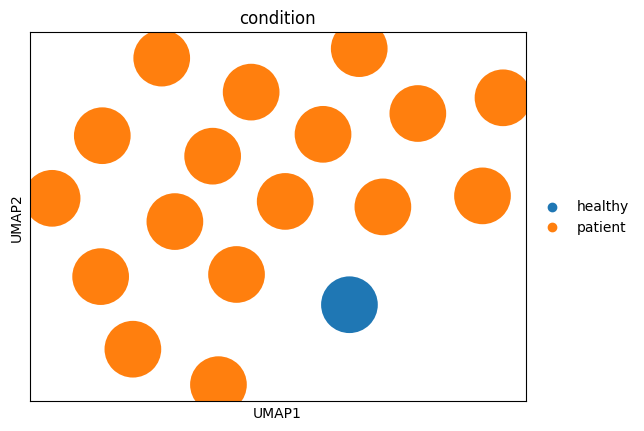

In [22]:
mantra.tl.neighbors(model, n_neighbors=min(10, len(metadata["sample_names"]) - 1))
mantra.tl.umap(model)

fig = mantra.pl.embedding(model, color="condition", method="umap")
plt.show()

### 9c. Leiden Clustering

/Users/Buettner/projects/MANTRA/mantra/analysis/embedding.py:98: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(cache.factor_adata, **kwargs)


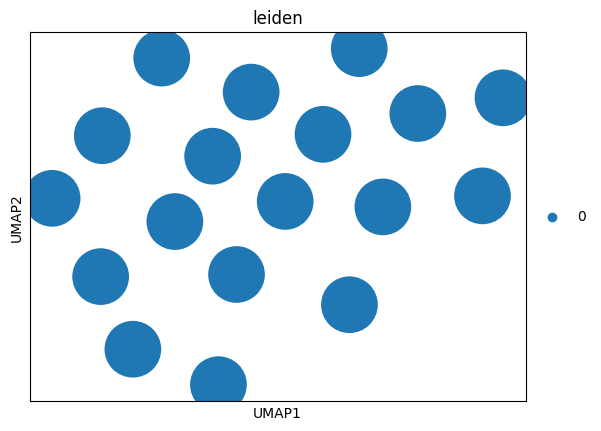

In [23]:
mantra.tl.leiden(model, resolution=0.5)

fig = mantra.pl.embedding(model, color="leiden", method="umap")
plt.show()

### 9d. Factor Scatter Plots

Visualize pairs of factors, colored by metadata.

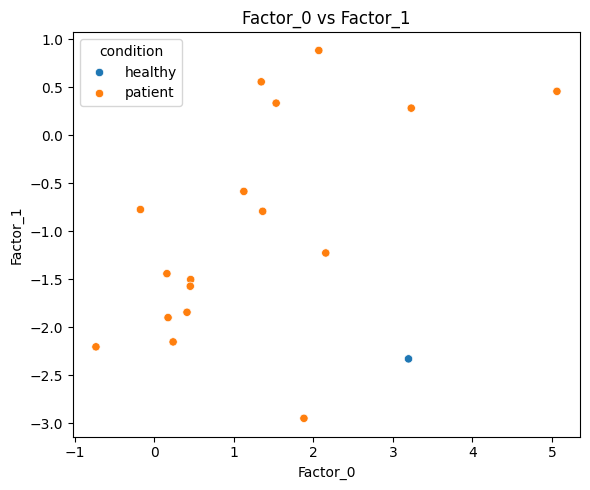

In [24]:
fig = mantra.pl.scatter(model, x=0, y=1, color="condition")
plt.show()

### 9e. Hierarchical Clustering

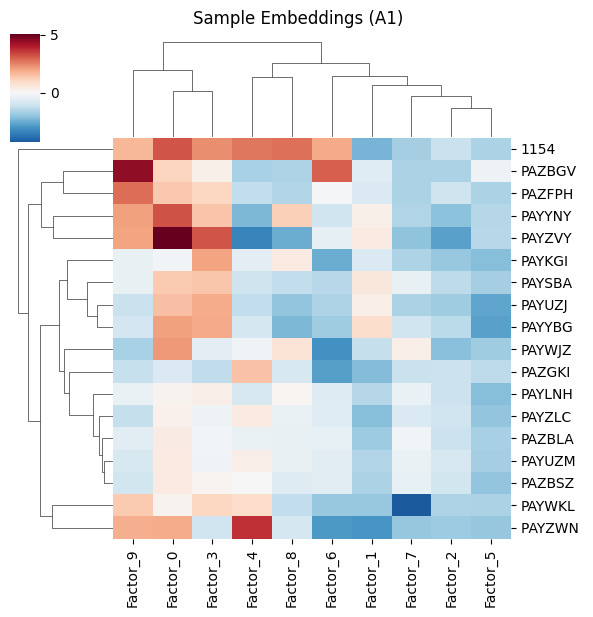

In [25]:
g = mantra.pl.clustermap(model)
plt.show()

## 10. Reconstruction Quality

In [26]:
Y_hat = model.get_reconstructed()
rmse = mantra.tl.rmse_loss(Y_hat, tensor_norm)
print(f"Reconstruction RMSE: {rmse:.4f}")

Reconstruction RMSE: 0.2884


## Summary

This tutorial demonstrated the full MANTRA workflow on real scRNA-seq data:

| Step | Functions Used |
|------|---------------|
| Feature selection | `mantra.pp.highly_variable_features()` |
| Pseudo-bulk | `mantra.pp.pseudobulk()` |
| Normalization | `mantra.pp.normalize()` |
| Model fitting | `MANTRA(...).fit()` |
| Variance explained | `mantra.tl.variance_explained()`, `mantra.tl.filter_factors()` |
| Factor interpretation | `mantra.pl.slice_weights()`, `mantra.pl.factor_weights()` |
| Pathway enrichment | `mantra.tl.enrichment()` (GSEA / ORA via gseapy) |
| UMAP + clustering | `mantra.tl.neighbors()`, `mantra.tl.umap()`, `mantra.tl.leiden()` |
| Visualization | `mantra.pl.embedding()`, `mantra.pl.scatter()`, `mantra.pl.clustermap()` |

Next: [03_cite_seq_protein.ipynb](03_cite_seq_protein.ipynb) shows MANTRA on
CITE-seq surface protein data.